Segmentación de instancias con YOLO: placas, vehículos y personas
En el tutorial anterior entrenamos un detector que encuentra placas y dibuja una caja alrededor de cada una. Una caja es útil, pero es una aproximación: incluye pedazos de fondo y no sigue la forma real del objeto.

La segmentación va un paso más allá: el modelo dice, píxel por píxel, qué parte de la imagen pertenece a cada objeto. El resultado es una máscara.

Tarea	Pregunta que responde	Salida
Clasificación	¿Qué hay en la imagen?	Una etiqueta por imagen
Detección	¿Qué hay y dónde está?	Una caja + clase + confianza por objeto
Segmentación	¿Qué píxeles pertenecen a cada objeto?	Una máscara + clase + confianza por objeto
En este tutorial entrenaremos un modelo que segmenta placas, vehículos, motos y personas en las mismas fotos del dataset de placas.

Tipos de segmentación
Semántica: pinta cada píxel con su clase ("esto es vehículo"), pero no separa un auto de otro.
De instancias: separa cada objeto: "vehículo 1", "vehículo 2"... Es lo que hace YOLO y lo que haremos aquí.
Panóptica: combina las dos (objetos separados + fondo clasificado).
Plan del notebook
Entender qué es una máscara con un modelo preentrenado.
Resolver un problema real: nuestro dataset solo tiene cajas, no máscaras.
Generar las máscaras automáticamente con SAM (placas) y un modelo de COCO (las demás clases).
Entrenar un modelo yolo26n-seg con las 4 clases.
Evaluar: IoU de máscaras y mAP de máscaras.
Una aplicación práctica: anonimizar placas y recortar vehículos.
1. Preparación del entorno
Usamos la misma librería que en detección, Ultralytics, que también incluye modelos de segmentación y el modelo SAM. Si no está instalada:

uv add ultralytics
Las rutas:

DATA_DIR: el dataset original de placas (solo cajas).
SEG_DIR: el nuevo dataset de segmentación que vamos a construir en este notebook.
RUNS_DIR: donde se guardan los entrenamientos. Como en el tutorial de detección, las rutas son absolutas para que Ultralytics no las guarde en su carpeta global.

In [1]:
from pathlib import Path
import random
import shutil
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image, ImageDraw, ImageFilter

import ultralytics
from ultralytics import SAM, YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    DEVICE = 0              # primera GPU NVIDIA
elif torch.backends.mps.is_available():
    DEVICE = "mps"          # GPU de Apple (M1/M2/M3...)
else:
    DEVICE = "cpu"

warnings.filterwarnings("ignore", message=".*does not have a deterministic implementation.*")

DATA_DIR = Path("../data/license-plates").resolve()        # dataset original (cajas)
SEG_DIR = Path("../data/license-plates-seg").resolve()     # dataset de segmentación (lo creamos aquí)
RUNS_DIR = Path("runs").resolve()

print(f"Ultralytics {ultralytics.__version__} | PyTorch {torch.__version__} | Dispositivo: {DEVICE}")

Ultralytics 8.4.170 | PyTorch 2.14.0+cpu | Dispositivo: cpu


In [2]:
def mostrar(imagen, titulo=None, ax=None, figsize=(8, 6)):
    # Muestra una imagen (ruta, PIL o arreglo RGB) con matplotlib.
    if isinstance(imagen, (str, Path)):
        imagen = Image.open(imagen)
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    ax.imshow(imagen)
    ax.axis("off")
    if titulo:
        ax.set_title(titulo, fontsize=10)
    return ax


def caja_real(ruta_img):
    # Cajas de placa del dataset original, en píxeles (x1, y1, x2, y2). Una fila por placa.
    ruta_img = Path(ruta_img)
    ancho, alto = Image.open(ruta_img).size
    etiquetas = np.loadtxt(DATA_DIR / "labels" / ruta_img.parent.name / f"{ruta_img.stem}.txt", ndmin=2)
    xc, yc, w, h = etiquetas[:, 1], etiquetas[:, 2], etiquetas[:, 3], etiquetas[:, 4]
    return np.stack([(xc - w / 2) * ancho, (yc - h / 2) * alto, (xc + w / 2) * ancho, (yc + h / 2) * alto], axis=1)


def poligono_a_mascara(poligono, ancho, alto):
    # Polígono en píxeles [[x, y], ...] → máscara booleana de tamaño (alto, ancho).
    lienzo = Image.new("L", (ancho, alto), 0)
    ImageDraw.Draw(lienzo).polygon([tuple(p) for p in poligono], fill=1)
    return np.array(lienzo, dtype=bool)


imgs_train = sorted((DATA_DIR / "images" / "train").glob("*.jpg"))
imgs_val = sorted((DATA_DIR / "images" / "val").glob("*.jpg"))
print(f"Imágenes: {len(imgs_train)} de entrenamiento | {len(imgs_val)} de validación")

Imágenes: 1526 de entrenamiento | 169 de validación


In [3]:
modelo_coco = YOLO("yolo26n-seg.pt")     # se descarga la primera vez

ruta_ejemplo = imgs_val[0]
resultado = modelo_coco.predict(ruta_ejemplo, conf=0.5, device=DEVICE, verbose=False)[0]

print(f"Objetos encontrados: {len(resultado.boxes)}")
print("Clases:", [resultado.names[int(c)] for c in resultado.boxes.cls])
print(f"masks.data: {tuple(resultado.masks.data.shape)}  ← [objetos, alto, ancho] a la resolución de la red")
print(f"Polígono del primer objeto: {len(resultado.masks.xy[0])} puntos, por ejemplo {resultado.masks.xy[0][0].round(1)}")

Objetos encontrados: 2
Clases: ['car', 'person']
masks.data: (2, 512, 640)  ← [objetos, alto, ancho] a la resolución de la red
Polígono del primer objeto: 594 puntos, por ejemplo [      391.3       101.2]


In [ ]:
ruta_ejemplo = "../data/frutas.jpeg"
resultado = modelo_coco.predict(ruta_ejemplo, conf=0.5, device=DEVICE, verbose=False)[0]


ancho, alto = Image.open(ruta_ejemplo).size
mascara = poligono_a_mascara(resultado.masks.xy[2], ancho, alto)
nombre = resultado.names[int(resultado.boxes.cls[0])]

print(f"Máscara: forma {mascara.shape}, tipo {mascara.dtype}")
print(f"Píxeles del objeto: {mascara.sum():,} de {mascara.size:,} ({mascara.mean():.1%} de la imagen)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
mostrar(ruta_ejemplo, "Imagen original", ax=axes[0])
axes[1].imshow(mascara, cmap="gray")
axes[1].set_title(f"Máscara de '{nombre}' (blanco = 1, negro = 0)", fontsize=10)
axes[1].axis("off")
mostrar(resultado.plot()[..., ::-1], "resultado.plot(): cajas + máscaras de todos los objetos", ax=axes[2])
plt.tight_layout()
plt.show()

FileNotFoundError: ../data/frutas.jpeg does not exist

### 3. El modelo de COCO sobre nuestras fotos

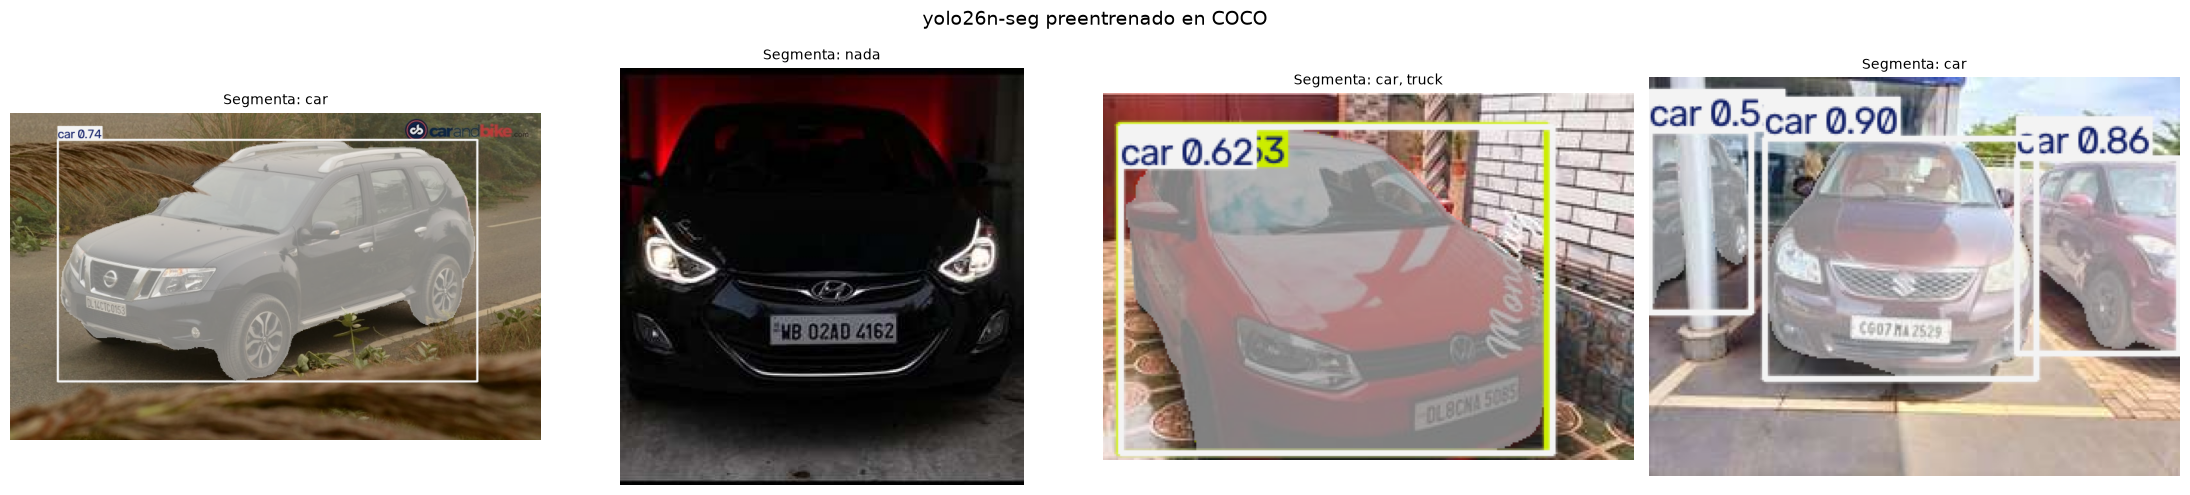

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, ruta in zip(axes, random.sample(imgs_train, 4)):
    resultado = modelo_coco.predict(ruta, conf=0.5, device=DEVICE, verbose=False)[0]
    clases = sorted({resultado.names[int(c)] for c in resultado.boxes.cls}) or ["nada"]
    mostrar(resultado.plot()[..., ::-1], "Segmenta: " + ", ".join(clases), ax=ax)
plt.suptitle("yolo26n-seg preentrenado en COCO", fontsize=14)
plt.tight_layout()
plt.show()

### 4. SAM: segmentar cualquier cosa

Área de la caja:    1,806 píxeles
Área de la máscara: 1,683 píxeles (93% de la caja)


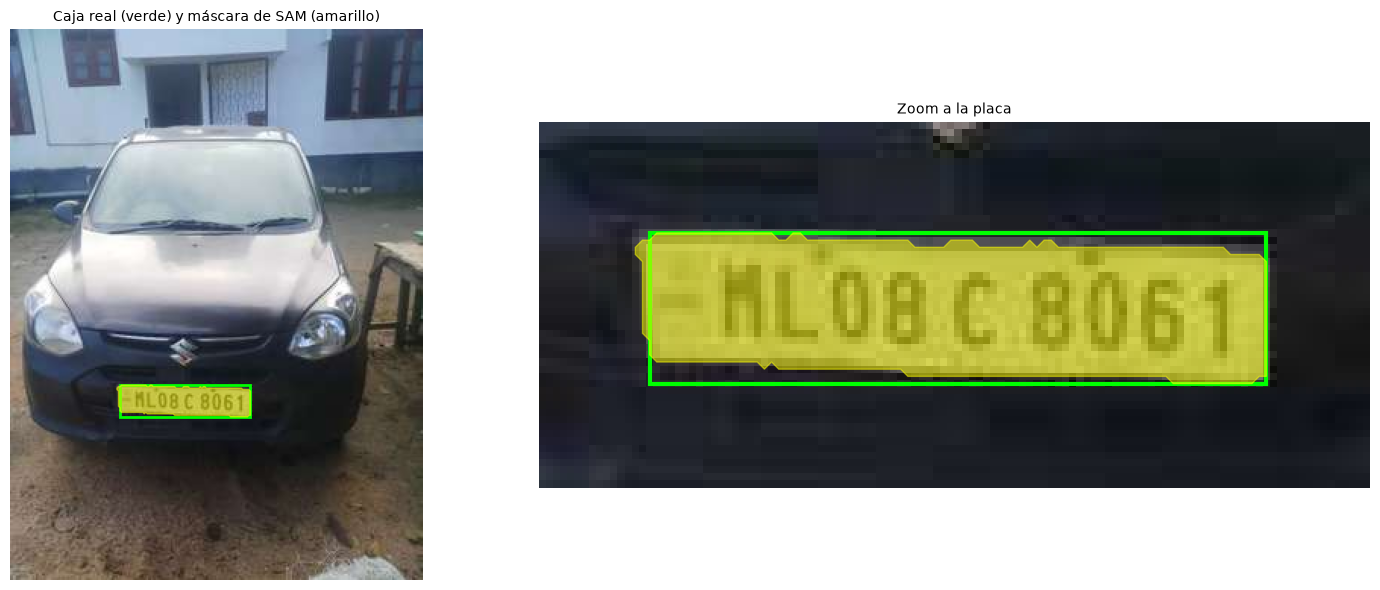

In [7]:
sam = SAM("sam2.1_t.pt")                       # se descarga la primera vez (~75 MB)

ruta_inclinada = DATA_DIR / "images" / "train" / "ML28.jpg"
caja = caja_real(ruta_inclinada)[0]            # la caja anotada por una persona
resultado_sam = sam(ruta_inclinada, bboxes=[caja.tolist()], device=DEVICE, verbose=False)[0]
poligono = resultado_sam.masks.xy[0]           # contorno de la placa, en píxeles

ancho, alto = Image.open(ruta_inclinada).size
mascara_placa = poligono_a_mascara(poligono, ancho, alto)
area_caja = (caja[2] - caja[0]) * (caja[3] - caja[1])
print(f"Área de la caja:    {area_caja:,.0f} píxeles")
print(f"Área de la máscara: {mascara_placa.sum():,} píxeles ({mascara_placa.sum() / area_caja:.0%} de la caja)")

x1, y1, x2, y2 = caja
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = mostrar(ruta_inclinada, "Caja real (verde) y máscara de SAM (amarillo)", ax=axes[0])
ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", lw=2))
ax.fill(poligono[:, 0], poligono[:, 1], color="yellow", alpha=0.5)

margen = 15
ax = mostrar(Image.open(ruta_inclinada).crop((x1 - margen, y1 - margen, x2 + margen, y2 + margen)), "Zoom a la placa", ax=axes[1])
ax.add_patch(plt.Rectangle((margen, margen), x2 - x1, y2 - y1, fill=False, edgecolor="lime", lw=3))
ax.fill(poligono[:, 0] - x1 + margen, poligono[:, 1] - y1 + margen, color="yellow", alpha=0.5)
plt.tight_layout()
plt.show()

### 5. Construir el dataset de segmentación (auto-etiquetado)

In [8]:
CLASES = {0: "license_plate", 1: "vehicle", 2: "motorcycle", 3: "person"}
COCO_A_NUESTRAS = {"car": 1, "truck": 1, "bus": 1, "motorcycle": 2, "person": 3}
CONF_PROFESOR = 0.5

profesor = YOLO("yolo26m-seg.pt")     # modelo de COCO más grande (~50 MB), solo para etiquetar


def linea_yolo(clase, poligono_normalizado):
    # Una línea del .txt: clase seguida de las coordenadas x y del polígono (entre 0 y 1).
    coordenadas = " ".join(f"{v:.5f}" for v in poligono_normalizado.reshape(-1))
    return f"{clase} {coordenadas}"


def etiquetar(ruta_img):
    # Devuelve las líneas del .txt de segmentación de una imagen.
    lineas = []

    # 1. Placas: SAM dibuja la máscara a partir de cada caja real
    cajas = caja_real(ruta_img)
    resultado = sam(ruta_img, bboxes=cajas.tolist(), device=DEVICE, verbose=False)[0]
    for poligono in resultado.masks.xyn:
        if len(poligono) >= 3:                        # un polígono necesita al menos 3 puntos
            lineas.append(linea_yolo(0, poligono))

    # 2. Vehículos, motos y personas: el modelo profesor de COCO
    resultado = profesor.predict(ruta_img, conf=CONF_PROFESOR, device=DEVICE, verbose=False)[0]
    if resultado.masks is not None:
        for clase_coco, poligono in zip(resultado.boxes.cls, resultado.masks.xyn):
            nombre = resultado.names[int(clase_coco)]
            if nombre in COCO_A_NUESTRAS and len(poligono) >= 3:
                lineas.append(linea_yolo(COCO_A_NUESTRAS[nombre], poligono))
    return lineas


# Probamos con la imagen de la placa inclinada
for linea in etiquetar(ruta_inclinada):
    valores = linea.split()
    print(f"clase {valores[0]} ({CLASES[int(valores[0])]}): {(len(valores) - 1) // 2} puntos → {' '.join(valores[:7])} ...")

clase 0 (license_plate): 43 puntos → 0 0.26838 0.64463 0.26471 0.64738 0.26103 0.64738 ...
clase 1 (vehicle): 492 puntos → 1 0.37326 0.17500 0.37117 0.17656 0.35658 0.17656 ...


In [ ]:
REGENERAR = True

if (SEG_DIR / "labels" / "val").exists() and not REGENERAR:
    print(f"El dataset de segmentación ya existe en {SEG_DIR}")
else:
    inicio = time.time()
    for split, imagenes in [("train", imgs_train), ("val", imgs_val)]:
        (SEG_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (SEG_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)
        for i, ruta in enumerate(imagenes, start=1):
            shutil.copy(ruta, SEG_DIR / "images" / split / ruta.name)
            (SEG_DIR / "labels" / split / f"{ruta.stem}.txt").write_text("\n".join(etiquetar(ruta)))
            if i % 250 == 0 or i == len(imagenes):
                print(f"  {split}: {i}/{len(imagenes)} imágenes ({(time.time() - inicio) / 60:.1f} min)")
    print(f"Dataset creado en {(time.time() - inicio) / 60:.1f} minutos")

  train: 250/1526 imágenes (24.1 min)
  train: 500/1526 imágenes (48.1 min)


In [ ]:
COLORES = {0: "yellow", 1: "tab:blue", 2: "tab:orange", 3: "tab:red"}


def leer_poligonos(ruta_txt):
    # Lee un .txt de segmentación → lista de (clase, polígono normalizado [n, 2]).
    poligonos = []
    for linea in Path(ruta_txt).read_text().splitlines():
        valores = np.array(linea.split(), dtype=float)
        poligonos.append((int(valores[0]), valores[1:].reshape(-1, 2)))
    return poligonos


def dibujar_poligonos(ax, ruta_img, poligonos, titulo=None):
    # Dibuja los polígonos (coordenadas normalizadas) rellenos sobre la imagen.
    imagen = Image.open(ruta_img)
    ancho, alto = imagen.size
    mostrar(imagen, titulo, ax=ax)
    for clase, poligono in poligonos:
        ax.fill(poligono[:, 0] * ancho, poligono[:, 1] * alto, color=COLORES[clase], alpha=0.45)
        ax.plot(poligono[:, 0] * ancho, poligono[:, 1] * alto, color=COLORES[clase], lw=1)


imgs_seg_train = sorted((SEG_DIR / "images" / "train").glob("*.jpg"))

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, ruta in zip(axes.flat, random.sample(imgs_seg_train, 8)):
    poligonos = leer_poligonos(SEG_DIR / "labels" / "train" / f"{ruta.stem}.txt")
    conteo = pd.Series([CLASES[c] for c, _ in poligonos]).value_counts()
    dibujar_poligonos(ax, ruta, poligonos, ", ".join(f"{n} ×{k}" for n, k in conteo.items()))
plt.suptitle("Etiquetas generadas | amarillo: placa, azul: vehículo, naranja: moto, rojo: persona", fontsize=14)
plt.tight_layout()
plt.show()